## Dependancy Preparation

In [ ]:
%pip -q uninstall -y gym || true
%pip -q install -U torchattacks stable-baselines3 gymnasium[atari] shimmy ale-py autorom[accept-rom-license] moviepy
%pip -q install -U torch torchvision --index-url https://download.pytorch.org/whl/cu121

!AutoROM --accept-license

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.7/434.7 kB 13.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.2/187.2 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.9/129.9 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 14.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the 

## Train

In [ ]:

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchattacks
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import ale_py
from dataclasses import dataclass
from collections import deque

import gymnasium as gym
from gymnasium.wrappers import RecordVideo

from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import CheckpointCallback
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack, VecVideoRecorder

torch.backends.cudnn.benchmark = True
warnings.filterwarnings("ignore", message=".*Gym has been unmaintained.*")

SEED = 0
N_ENVS = 4
N_STACK = 4
ENV_ID = "PongNoFrameskip-v4"

SAVE_NAME = "DQN_PONG"
MODEL_PATH = f"{SAVE_NAME}.zip"
DEVICE = "cuda"  if torch.cuda.is_available() else "cpu"
env = make_atari_env(ENV_ID, n_envs=N_ENVS, seed=SEED)
env = VecFrameStack(env, n_stack=N_STACK)


In [ ]:
ckpt_cb = CheckpointCallback(save_freq=250_000, save_path="checkpoints", name_prefix=SAVE_NAME)

model = DQN(
    "CnnPolicy",
    env,
    device=DEVICE,
    learning_rate=1e-4,
    buffer_size=200_000,
    learning_starts=100_000,
    batch_size=32,
    gamma=0.99,
    train_freq=4,
    gradient_steps=2,
    target_update_interval=1_000,
    exploration_fraction=0.10,
    exploration_final_eps=0.05,
    optimize_memory_usage=True,
    replay_buffer_kwargs={"handle_timeout_termination": False},
    tensorboard_log="runs_sb3",
    verbose=1,
)


TOTAL_STEPS = 2_000_000
model.learn(total_timesteps=TOTAL_STEPS, callback=ckpt_cb)
model.save(SAVE_NAME)
env.close()
print(f"Training complete. Model saved to {SAVE_NAME}.zip")


Using cuda device
Wrapping the env in a VecTransposeImage.
Logging to runs_sb3/DQN_3
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 3.93e+03 |
|    ep_rew_mean      | -20      |
|    exploration_rate | 0.979    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 451      |
|    time_elapsed     | 9        |
|    total_timesteps  | 4220     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 3.71e+03 |
|    ep_rew_mean      | -20.1    |
|    exploration_rate | 0.962    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 536      |
|    time_elapsed     | 14       |
|    total_timesteps  | 7580     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 3.74e+03 |
|    ep_rew_mean      | -20.2    |
|    

### Eval Video 

In [35]:
VIDEO_DIR = "videos_eval"
os.makedirs(VIDEO_DIR, exist_ok=True)

model = DQN.load(SAVE_NAME, device=DEVICE)
eval_env = make_atari_env(ENV_ID, n_envs=1, seed=123)
eval_env = VecFrameStack(eval_env, n_stack=N_STACK)

eval_env = VecVideoRecorder(
    eval_env,
    VIDEO_DIR,
    record_video_trigger=lambda step: step == 0,
    video_length=5000,
    name_prefix=SAVE_NAME,
)

obs = eval_env.reset()
for _ in range(5000):
    action, _ = model.predict(obs, deterministic=True)
    obs, rewards, dones, infos = eval_env.step(action)
    if dones[0]:
        break

eval_env.close()
print(f"Saved video(s) in: {VIDEO_DIR}")


MoviePy - Building video /content/videos_eval/DQN_PONG-step-0-to-step-5000.mp4.
MoviePy - Writing video /content/videos_eval/DQN_PONG-step-0-to-step-5000.mp4



MoviePy - Done !
MoviePy - video ready /content/videos_eval/DQN_PONG-step-0-to-step-5000.mp4
Saved video(s) in: videos_eval


## Attack Implementation

### Attacks Configs

In [36]:
EVAL_EPISODES=10
N_ENVS = 1

# Per-step attacks
EPS = 4/255
PGD_STEP_SIZE = EPS/2
PGD_STEPS = 4
PGD_RANDOM_START = True

# UAP params
NUM_SAMPLES     = 10000
FRAME_STRIDE    = 4
BATCH_SIZE      = 64
MAX_ITERS       = 5
UAP_EPS         = 4/255
PGD_STEPS_INNER = 4
PGD_ALPHA       = UAP_EPS/4
PGD_EPS_INNER   = UAP_EPS/2
PGD_RANDOM_START_INNER = False

### Helper Functions

In [ ]:
class QNetScaled255(nn.Module):
    """Wrap Q-network: feed [0,1], scale to [0,255] internally."""
    def __init__(self, q_net: nn.Module):
        super().__init__()
        self.q_net = q_net
    def forward(self, x_norm: torch.Tensor) -> torch.Tensor:
        if not torch.is_floating_point(x_norm):
            x_norm = x_norm.float()
        return self.q_net(x_norm * 255.0)


@dataclass
class AttackHelpers:
    env: any
    qnet: nn.Module
    policy: any

    def obs_to_norm01(self, obs_np: np.ndarray) -> torch.Tensor:
        x, _ = self.policy.obs_to_tensor(obs_np)
        if not torch.is_floating_point(x):
            x = x.float()
        if x.max() > 1.0:
            x = x / 255.0
        return x.clamp(0.0, 1.0)

    @torch.no_grad()
    def greedy_action(self, x_norm: torch.Tensor) -> np.ndarray:
        q = self.qnet(x_norm)
        return q.argmax(dim=1).cpu().numpy()

    @torch.no_grad()
    def greedy_label(self, x_norm: torch.Tensor) -> torch.Tensor:
        return self.qnet(x_norm).argmax(dim=1)

    def add_random_noise_norm(self, x_norm: torch.Tensor, eps: float, mode: str = "uniform") -> torch.Tensor:
        if eps == 0.0:
            return x_norm.clone()
        if mode == "uniform":
            noise = torch.empty_like(x_norm).uniform_(-eps, eps)
        elif mode == "gaussian":
            noise = torch.randn_like(x_norm) * (eps / 2.0)
        else:
            raise ValueError("mode must be 'uniform' or 'gaussian'")
        return (x_norm + noise).clamp(0.0, 1.0)

    def run_episode(self, strategy) -> float:
        obs = self.env.reset()
        ep_reward = np.zeros(N_ENVS, dtype=np.float32)
        dones = np.array([False] * N_ENVS)

        while not dones.all():
            x_norm = self.obs_to_norm01(obs).to(DEVICE)
            x_att = strategy(x_norm)
            actions = self.greedy_action(x_att)
            obs, rewards, dones, infos = self.env.step(actions)
            ep_reward += rewards
        return float(ep_reward.mean())


class FrameDataset(Dataset):
    def __init__(self, frames: torch.Tensor):
        self.frames = frames
    def __len__(self): return self.frames.shape[0]
    def __getitem__(self, i): return self.frames[i]


@torch.no_grad()
def collect_frames(helpers: AttackHelpers, num_samples: int, stride: int = 1) -> torch.Tensor:
    obs = helpers.env.reset()
    frames = []
    t = 0
    while len(frames) < num_samples:
        x = helpers.obs_to_norm01(obs)
        actions = helpers.greedy_action(x)
        obs, rewards, dones, infos = helpers.env.step(actions)
        if t % stride == 0:
            frames.append(x.squeeze(0).cpu())
        if dones[0]:
            obs = helpers.env.reset()
        t += 1
    return torch.stack(frames, dim=0)[:num_samples]


@dataclass
class UAPConfig:
    eps: float = UAP_EPS
    eps_inner: float = PGD_EPS_INNER
    alpha: float = PGD_ALPHA
    steps: int = PGD_STEPS_INNER
    random_start: bool = PGD_RANDOM_START_INNER
    max_iters: int = MAX_ITERS


class UAP_PGD:
    def __init__(self, helpers: AttackHelpers, cfg: UAPConfig):
        self.h = helpers
        self.cfg = cfg
        self.uap = None
        self._pgd = torchattacks.PGD(
            self.h.qnet,
            eps=self.cfg.eps_inner,
            alpha=self.cfg.alpha,
            steps=self.cfg.steps,
            random_start=self.cfg.random_start,
        )

    def generate(self, data_loader: DataLoader) -> torch.Tensor:
        for xb in data_loader:
            C, H, W = xb.shape[1], xb.shape[2], xb.shape[3]
            break
        self.uap = torch.zeros(1, C, H, W, device=DEVICE)

        total_batches = len(data_loader)
        for it in range(self.cfg.max_iters):
            fooled, total = 0, 0
            for batch_idx, x_clean in enumerate(data_loader):
                x_clean = x_clean.to(DEVICE)
                with torch.no_grad():
                    y_clean = self.h.greedy_label(x_clean)

                x_tilde = (x_clean + self.uap).clamp(0.0, 1.0)
                with torch.no_grad():
                    y_tilde = self.h.greedy_label(x_tilde)
                mask = (y_tilde == y_clean)
                idx = mask.nonzero(as_tuple=False).view(-1)

                total += x_clean.size(0)
                fooled += (mask.numel() - idx.numel())

                if idx.numel() == 0: continue

                x_t_subset = x_tilde[idx].detach()
                labels_subset = y_clean[idx]
                x_adv_subset = self._pgd(x_t_subset, labels_subset)
                v = (x_adv_subset - x_t_subset).mean(dim=0, keepdim=True)

                self.uap = (self.uap + v).clamp(-self.cfg.eps, self.cfg.eps).detach()

                del x_t_subset, labels_subset, x_adv_subset, v

            fool_rate = fooled / max(1, total)
            print(f"[UAP][iter {it+1}/{self.cfg.max_iters}] batches={total_batches} | fool_rate: {fool_rate:.3f}")

        return self.uap.detach()

    def apply(self, x_norm: torch.Tensor) -> torch.Tensor:
        return (x_norm + self.uap).clamp(0.0, 1.0)
    

### Testing Attacks

In [ ]:
sb3_model = DQN.load(SAVE_NAME, device=DEVICE)
env = make_atari_env(ENV_ID, n_envs=N_ENVS, seed=SEED)
env = VecFrameStack(env, n_stack=N_STACK)

policy = sb3_model.policy.eval()
qnet = QNetScaled255(policy.q_net).to(DEVICE).eval()
helpers = AttackHelpers(env=env, qnet=qnet, policy=policy)


atk_fgsm = torchattacks.FGSM(qnet, eps=EPS)
atk_pgd  = torchattacks.PGD(qnet, eps=EPS, alpha=PGD_STEP_SIZE, steps=PGD_STEPS, random_start=PGD_RANDOM_START)

def strat_clean(x): return x
def strat_fgsm(x): return atk_fgsm(x, helpers.greedy_label(x))
def strat_pgd(x):  return atk_pgd(x, helpers.greedy_label(x))
def make_strat_rand(mode, eps): return lambda x: helpers.add_random_noise_norm(x, eps, mode)

RUN_MODES = {
    "clean": strat_clean,
    "fgsm": strat_fgsm,
    "pgd": strat_pgd,
    "rand-uniform": make_strat_rand("uniform", EPS),
    "rand-gaussian": make_strat_rand("gaussian", EPS),
}

results = {}
for name, strat in RUN_MODES.items():
    scores = [helpers.run_episode(strat) for _ in range(EVAL_EPISODES)]
    results[name] = (scores, float(np.mean(scores)))

print("========================================")
print(f"Device: {DEVICE}")
print(f"EPS: {EPS:.6f} (~{EPS*255:.1f}/255)")
print("----------------------------------------")
for mode, (scores, mean_score) in results.items():
    print(f"{mode:13s} mean: {mean_score:6.2f} | per-ep: {scores}")
print("========================================")


frames = collect_frames(helpers, NUM_SAMPLES, FRAME_STRIDE)
loader = DataLoader(frames, batch_size=BATCH_SIZE, shuffle=True, drop_last=False, pin_memory=True)

uap = UAP_PGD(helpers, UAPConfig())
print(f"[uap] Training with eps={UAP_EPS:.6f} (~{UAP_EPS*255:.1f}/255)")
u = uap.generate(loader)
print("[uap] Done. stats:", "min", float(u.min()), "max", float(u.max()), "Linf*255", float(u.abs().max()*255))

def strat_uap(x): return uap.apply(x)
clean_scores = [helpers.run_episode(strat_clean) for _ in range(EVAL_EPISODES)]
uap_scores   = [helpers.run_episode(strat_uap)   for _ in range(EVAL_EPISODES)]

env.close()
print("========================================")
print(f"Clean mean ({EVAL_EPISODES}): {np.mean(clean_scores):.2f} | per-ep: {clean_scores}")
print(f"UAP   mean ({EVAL_EPISODES}): {np.mean(uap_scores):.2f} | per-ep: {uap_scores}")
print("========================================")

Device: cuda
EPS: 0.015686 (~4.0/255)
----------------------------------------
clean         mean:  20.30 | per-ep: [20.0, 21.0, 21.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 21.0]
fgsm          mean: -21.00 | per-ep: [-21.0, -21.0, -21.0, -21.0, -21.0, -21.0, -21.0, -21.0, -21.0, -21.0]
pgd           mean: -21.00 | per-ep: [-21.0, -21.0, -21.0, -21.0, -21.0, -21.0, -21.0, -21.0, -21.0, -21.0]
rand-uniform  mean:  20.30 | per-ep: [20.0, 21.0, 21.0, 20.0, 20.0, 20.0, 21.0, 20.0, 20.0, 20.0]
rand-gaussian mean:  20.60 | per-ep: [20.0, 20.0, 21.0, 20.0, 21.0, 21.0, 20.0, 21.0, 21.0, 21.0]
[uap] Training with eps=0.015686 (~4.0/255)
[UAP][iter 1/5] batches=157 | fool_rate: 0.840
[UAP][iter 2/5] batches=157 | fool_rate: 0.841
[UAP][iter 3/5] batches=157 | fool_rate: 0.844
[UAP][iter 4/5] batches=157 | fool_rate: 0.857
[UAP][iter 5/5] batches=157 | fool_rate: 0.848
[uap] Done. stats: min -0.01568627543747425 max 0.01568627543747425 Linf*255 4.0
Clean mean (10): 20.20 | per-ep: [21.0, 20.0, 20.0,

### Plot over Epsilon size

[collect] Collecting frames once for UAP training: N=10000, stride=4

[Sweep] ε = 0.000100 (~0.026/255)
[FGSM] mean reward: 19.300
[PGD ] mean reward: 19.600
[UAP ] training: eps=0.000100, eps_inner=0.000050, alpha=0.000025
[UAP][iter 1/5] batches=157 | fool_rate: 0.074
[UAP][iter 2/5] batches=157 | fool_rate: 0.079
[UAP][iter 3/5] batches=157 | fool_rate: 0.079
[UAP][iter 4/5] batches=157 | fool_rate: 0.079
[UAP][iter 5/5] batches=157 | fool_rate: 0.077
[UAP ] mean reward: 19.500
[Rand-uniform] mean reward: 20.100
[Rand-gaussian] mean reward: 20.400

[Sweep] ε = 0.000600 (~0.153/255)
[FGSM] mean reward: -17.600
[PGD ] mean reward: -19.800
[UAP ] training: eps=0.000600, eps_inner=0.000300, alpha=0.000150
[UAP][iter 1/5] batches=157 | fool_rate: 0.433
[UAP][iter 2/5] batches=157 | fool_rate: 0.468
[UAP][iter 3/5] batches=157 | fool_rate: 0.472
[UAP][iter 4/5] batches=157 | fool_rate: 0.475
[UAP][iter 5/5] batches=157 | fool_rate: 0.475
[UAP ] mean reward: 20.500
[Rand-uniform] mean rewa

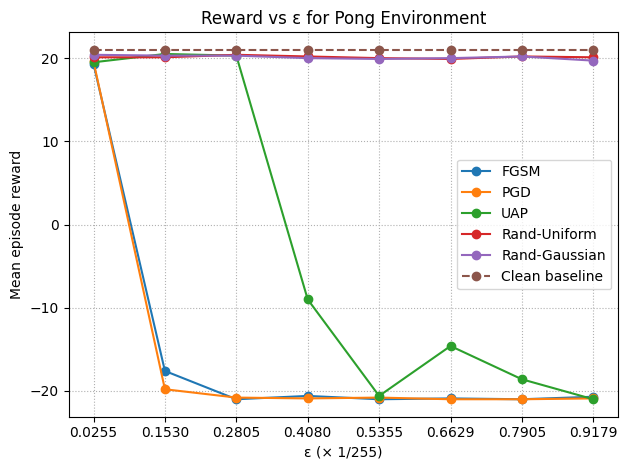

In [ ]:
eps_schedule = list(np.arange(0.0001, 0.004 + 1e-9, 0.0005))

clean_scores = [helpers.run_episode(strat_clean) for _ in range(EVAL_EPISODES)]
clean_mean = float(np.mean(clean_scores))


def eval_strategy(strategy, n=EVAL_EPISODES):
    scores = [helpers.run_episode(strategy) for _ in range(n)]
    return float(np.mean(scores))

records = []
for eps in eps_schedule:
    print("\n" + "="*60)
    print(f"[Sweep] ε = {eps:.6f} (~{eps*255:.3f}/255)")

    # ---- FGSM ----
    atk_fgsm = torchattacks.FGSM(qnet, eps=eps)
    def strat_fgsm(x): return atk_fgsm(x, helpers.greedy_label(x))
    mean_fgsm = eval_strategy(strat_fgsm)
    print(f"[FGSM] mean reward: {mean_fgsm:.3f}")

    # ---- PGD ----
    alpha = eps / 2
    atk_pgd = torchattacks.PGD(qnet, eps=eps, alpha=alpha, steps=4, random_start=True)
    def strat_pgd(x): return atk_pgd(x, helpers.greedy_label(x))
    mean_pgd = eval_strategy(strat_pgd)
    print(f"[PGD ] mean reward: {mean_pgd:.3f}")

    # ---- UAP ----
    eps_inner = eps / 2
    alpha_inner = eps / 4
    uap_cfg = UAPConfig(eps=eps, eps_inner=eps_inner, alpha=alpha_inner)
    uap = UAP_PGD(helpers, uap_cfg)
    print(f"[UAP ] training: eps={eps:.6f}, eps_inner={eps_inner:.6f}, alpha={alpha_inner:.6f}")
    uap.generate(loader)
    def strat_uap(x): return uap.apply(x)
    mean_uap = eval_strategy(strat_uap)
    print(f"[UAP ] mean reward: {mean_uap:.3f}")

    # ---- Random noise (uniform / gaussian) ----
    def strat_rand_uniform(x): return helpers.add_random_noise_norm(x, eps=eps, mode="uniform")
    def strat_rand_gaussian(x): return helpers.add_random_noise_norm(x, eps=eps, mode="gaussian")

    mean_rand_uniform = eval_strategy(strat_rand_uniform)
    mean_rand_gaussian = eval_strategy(strat_rand_gaussian)
    print(f"[Rand-uniform] mean reward: {mean_rand_uniform:.3f}")
    print(f"[Rand-gaussian] mean reward: {mean_rand_gaussian:.3f}")

    # ---- Record all ----
    records.append({
        "eps": eps,
        "eps_x255": eps * 255.0,
        "clean": clean_mean,
        "fgsm": mean_fgsm,
        "pgd": mean_pgd,
        "uap": mean_uap,
        "rand-uniform": mean_rand_uniform,
        "rand-gaussian": mean_rand_gaussian,
    })


df = pd.DataFrame.from_records(records).sort_values("eps_x255").reset_index(drop=True)
x = df["eps_x255"].values
print("\n=== Summary (mean rewards) ===")
print(df)

plt.figure()
plt.plot(x, df["fgsm"].values, marker="o", label="FGSM")
plt.plot(x, df["pgd"].values, marker="o", label="PGD")
plt.plot(x, df["uap"].values, marker="o", label="UAP")
plt.plot(x, df["rand-uniform"].values, marker="o", label="Rand-Uniform")
plt.plot(x, df["rand-gaussian"].values, marker="o", label="Rand-Gaussian")
plt.plot(x, df["clean"].values, linestyle="--", marker="o", label="Clean baseline")

plt.xlabel("ε (× 1/255)")
plt.ylabel("Mean episode reward")
plt.title("Reward vs ε for Pong Environment")
plt.xticks(x, [str(v)[:6] for v in x])
plt.legend()
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

### Video Recording

#### Helper Functions

In [ ]:

def _upscale_nearest(img_uint8_hwc: np.ndarray, scale: int) -> np.ndarray:
    img = np.repeat(img_uint8_hwc, scale, axis=0)
    img = np.repeat(img, scale, axis=1)
    return img

UPSCALE = 4

def _to_uint8_img_from_norm01(x_norm_bchw: torch.Tensor) -> np.ndarray:
    """
    x_norm_bchw: [1,C,H,W] in [0,1] -> uint8 HxWx3 (most recent channel),
    then upscale with nearest-neighbor.
    """
    x = x_norm_bchw[0]                    
    ch = x[-1].clamp(0, 1)                
    img = (ch * 255.0).round().to(torch.uint8).cpu().numpy()   
    img = np.stack([img, img, img], axis=-1)                    
    if UPSCALE and UPSCALE > 1:
        img = _upscale_nearest(img, UPSCALE)
    return img


def _raw_obs_to_norm01_bchw(obs_np, expected_chw, stack_buffer):
    """
    Convert raw obs to [1,Cexp,Hexp,Wexp] in [0,1], maintaining a rolling stack.
    - Seeds the buffer with Cexp copies of the first frame.
    """
    Cexp, Hexp, Wexp = expected_chw

    if isinstance(obs_np, tuple) and len(obs_np) == 2:
        obs_np, _ = obs_np

    if not isinstance(obs_np, np.ndarray):
        obs_np = np.array(obs_np)

    obs_f = obs_np.astype(np.float32) if obs_np.dtype != np.float32 else obs_np
    if obs_f.max() > 1.0:
        obs_f = obs_f / 255.0

    if obs_f.ndim == 2:                   
        hw = torch.from_numpy(obs_f)[None, ...]                
    elif obs_f.ndim == 3:
        # guess HxWxC vs CxHxW
        if obs_f.shape[0] in (1, 3, 4) and obs_f.shape[1:] == (Hexp, Wexp):
            chw = torch.from_numpy(obs_f)                       
        elif obs_f.shape[2] in (1, 3, 4) and obs_f.shape[0:2] == (Hexp, Wexp):
            chw = torch.from_numpy(obs_f).permute(2, 0, 1)    
        else:
            chw = torch.from_numpy(obs_f).permute(2, 0, 1)     
        if chw.shape[0] == 1:
            hw = chw                                       
        else:
            c = chw.shape[0]
            if c >= Cexp:
                hw = chw[-Cexp:]
            else:
                pad = chw[-1:].repeat(Cexp - c, 1, 1)
                hw = torch.cat([chw, pad], dim=0)             
    else:
        hw = torch.from_numpy(np.squeeze(obs_f)).float()
        if hw.ndim == 2:
            hw = hw[None, ...]
        else:
            hw = hw[-1][None, ...]

    if stack_buffer is None:
        from collections import deque
        stack_buffer = deque(maxlen=Cexp)

        for _ in range(Cexp):
            stack_buffer.append(hw.clone())
    elif len(stack_buffer) == 0:
        for _ in range(Cexp):
            stack_buffer.append(hw.clone())
    else:
        stack_buffer.append(hw.clone())

    stacked = torch.cat(list(stack_buffer), dim=0)  # [C?,H,W]
    if stacked.shape[0] < Cexp:
        pad = stacked[-1:].repeat(Cexp - stacked.shape[0], 1, 1)
        stacked = torch.cat([stacked, pad], dim=0)
    elif stacked.shape[0] > Cexp:
        stacked = stacked[-Cexp:]

    Cnow, Hnow, Wnow = stacked.shape
    if (Hnow, Wnow) != (Hexp, Wexp):
        Hmin, Wmin = min(Hnow, Hexp), min(Wnow, Wexp)
        stacked = stacked[:, :Hmin, :Wmin]
        if (Hmin, Wmin) != (Hexp, Wexp):
            pad_h = Hexp - Hmin
            pad_w = Wexp - Wmin
            stacked = torch.nn.functional.pad(stacked, (0, pad_w, 0, pad_h))

    x_norm = stacked.clamp(0, 1).unsqueeze(0)  #
    return x_norm, stack_buffer


class AdversarialRenderWrapper(gym.Wrapper):
    """
    Renders either attacked frames or side-by-side clean|attacked.
    Compatible with Gymnasium API.
    """
    def __init__(self, env, helpers, strategy, mode="attacked"):
        super().__init__(env)
        assert mode in ("attacked", "side_by_side")
        self.h = helpers
        self.strategy = strategy
        self.mode = mode
        self.last_frame = None
        # what policy expects, e.g., (C=4,84,84)
        self.expected_chw = tuple(self.h.policy.observation_space.shape)
        self._stack_buffer = None  

    def _compose_frame(self, obs):
        x_clean, self._stack_buffer = _raw_obs_to_norm01_bchw(
            obs, self.expected_chw, self._stack_buffer
        ) 
        x_att = self.strategy(x_clean.to(DEVICE))    
        clean_img = _to_uint8_img_from_norm01(x_clean)
        attacked_img = _to_uint8_img_from_norm01(x_att.cpu())

        if self.mode == "attacked":
            return attacked_img
        else:
            h = min(clean_img.shape[0], attacked_img.shape[0])
            clean = clean_img[:h]
            attacked = attacked_img[:h]
            return np.concatenate([clean, attacked], axis=1)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.last_frame = self._compose_frame(obs)
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self.last_frame = self._compose_frame(obs)
        return obs, reward, terminated, truncated, info

    def render(self):
        if self.last_frame is not None:
            return self.last_frame
        return self.env.render()


def record_episode_video(env_vec, helpers, strategy, video_dir, name_prefix,
                         episode_max_steps=10000, mode="attacked", fps=30):
    """
    Record one episode while rendering the *attacked* (or side-by-side) frames.

    env_vec: your SB3 VecEnv (make_atari_env + VecFrameStack with n_envs=1)
    helpers: AttackHelpers
    strategy: function x_norm->[x_adv]
    mode: "attacked" or "side_by_side"
    """

    os.makedirs(video_dir, exist_ok=True)
    raw_env = env_vec.envs[0]

    wrapped_env = AdversarialRenderWrapper(raw_env, helpers, strategy, mode=mode)
    rec_env = RecordVideo(
        wrapped_env,
        video_dir,
        name_prefix=name_prefix,
        episode_trigger=lambda eid: True,
        disable_logger=False,
    )

    obs, info = rec_env.reset()
    ep_reward, steps = 0.0, 0

    expected_chw = tuple(helpers.policy.observation_space.shape)
    stack_buffer = deque(maxlen=expected_chw[0])

    while steps < episode_max_steps:
        x_clean, stack_buffer = _raw_obs_to_norm01_bchw(obs, expected_chw, stack_buffer)  
        x_att = strategy(x_clean.to(DEVICE))
        action = helpers.greedy_action(x_att)
        if isinstance(action, np.ndarray):
            action = int(action.item())

        obs, reward, terminated, truncated, info = rec_env.step(action)
        ep_reward += float(reward)
        steps += 1
        if terminated or truncated:
            break

    rec_env.close()
    print(f"[Video] {name_prefix} | steps={steps} reward={ep_reward:.2f}")
    return ep_reward

#### Recording

In [ ]:
VIDEO_MODE = "attacked"
VIDEO_DIR = "videos_attacked"

eps_values = [0.01/255, 0.1/255, 1/255, 2/255]

record_episode_video(env, helpers, strat_clean, VIDEO_DIR, f"clean", mode=VIDEO_MODE)

for eps in eps_values:
    print("\n" + "="*70)
    print(f"[Videos] ε = {eps:.6f} (~{eps*255:.3f}/255)")

    # FGSM
    atk_fgsm = torchattacks.FGSM(helpers.qnet, eps=eps)
    def strat_fgsm(x): return atk_fgsm(x, helpers.greedy_label(x))
    record_episode_video(env, helpers, strat_fgsm, VIDEO_DIR, f"fgsm_eps_{eps*255:.3f}", mode=VIDEO_MODE)

    # PGD
    alpha = min(eps/2, 1/255)
    atk_pgd = torchattacks.PGD(helpers.qnet, eps=eps, alpha=alpha, steps=4, random_start=True)
    def strat_pgd(x): return atk_pgd(x, helpers.greedy_label(x))
    record_episode_video(env, helpers, strat_pgd, VIDEO_DIR, f"pgd_eps_{eps*255:.3f}", mode=VIDEO_MODE)

    # Random noise
    def strat_rand_uniform(x): return helpers.add_random_noise_norm(x, eps=eps, mode="uniform")
    def strat_rand_gaussian(x): return helpers.add_random_noise_norm(x, eps=eps, mode="gaussian")
    record_episode_video(env, helpers, strat_rand_uniform, VIDEO_DIR, f"rand_uniform_eps_{eps*255:.3f}", mode=VIDEO_MODE)
    record_episode_video(env, helpers, strat_rand_gaussian, VIDEO_DIR, f"rand_gaussian_eps_{eps*255:.3f}", mode=VIDEO_MODE)

    # UAP (fresh per ε)
    eps_inner = min(eps/2, 2/255)
    alpha_inner = min(eps/4, 2/255)
    uap_cfg = UAPConfig(eps=eps, eps_inner=eps_inner, alpha=alpha_inner)
    uap = UAP_PGD(helpers, uap_cfg)
    print(f"[UAP ] training: eps={eps:.6f}, eps_inner={eps_inner:.6f}, alpha_inner={alpha_inner:.6f}")
    uap.generate(loader)
    def strat_uap(x): return uap.apply(x)
    record_episode_video(env, helpers, strat_uap, VIDEO_DIR, f"uap_eps_{eps*255:.3f}", mode=VIDEO_MODE)

print("Saved to:", os.path.abspath(VIDEO_DIR))


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:296: UserWarning: WARN: Overwriting existing videos at /content/videos_attacked folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


MoviePy - Building video /content/videos_attacked/clean-episode-0.mp4.
MoviePy - Writing video /content/videos_attacked/clean-episode-0.mp4



MoviePy - Done !
MoviePy - video ready /content/videos_attacked/clean-episode-0.mp4
[Video] clean | steps=1711 reward=20.00

[Videos] ε = 0.000039 (~0.010/255)
MoviePy - Building video /content/videos_attacked/fgsm_eps_0.010-episode-0.mp4.
MoviePy - Writing video /content/videos_attacked/fgsm_eps_0.010-episode-0.mp4



MoviePy - Done !
MoviePy - video ready /content/videos_attacked/fgsm_eps_0.010-episode-0.mp4
[Video] fgsm_eps_0.010 | steps=1727 reward=20.00
MoviePy - Building video /content/videos_attacked/pgd_eps_0.010-episode-0.mp4.
MoviePy - Writing video /content/videos_attacked/pgd_eps_0.010-episode-0.mp4



MoviePy - Done !
MoviePy - video ready /content/videos_attacked/pgd_eps_0.010-episode-0.mp4
[Video] pgd_eps_0.010 | steps=1759 reward=20.00
MoviePy - Building video /content/videos_attacked/rand_uniform_eps_0.010-episode-0.mp4.
MoviePy - Writing video /content/videos_attacked/rand_uniform_eps_0.010-episode-0.mp4



...

MoviePy - Done !
MoviePy - video ready /content/videos_attacked/fgsm_eps_2.000-episode-0.mp4
[Video] fgsm_eps_2.000 | steps=756 reward=-21.00
MoviePy - Building video /content/videos_attacked/pgd_eps_2.000-episode-0.mp4.
MoviePy - Writing video /content/videos_attacked/pgd_eps_2.000-episode-0.mp4



MoviePy - Done !
MoviePy - video ready /content/videos_attacked/pgd_eps_2.000-episode-0.mp4
[Video] pgd_eps_2.000 | steps=783 reward=-21.00
MoviePy - Building video /content/videos_attacked/rand_uniform_eps_2.000-episode-0.mp4.
MoviePy - Writing video /content/videos_attacked/rand_uniform_eps_2.000-episode-0.mp4



MoviePy - Done !
MoviePy - video ready /content/videos_attacked/rand_uniform_eps_2.000-episode-0.mp4
[Video] rand_uniform_eps_2.000 | steps=1693 reward=20.00
MoviePy - Building video /content/videos_attacked/rand_gaussian_eps_2.000-episode-0.mp4.
MoviePy - Writing video /content/videos_attacked/rand_gaussian_eps_2.000-episode-0.mp4



MoviePy - Done !
MoviePy - video ready /content/videos_attacked/rand_gaussian_eps_2.000-episode-0.mp4
[Video] rand_gaussian_eps_2.000 | steps=1749 reward=20.00
[UAP ] training: eps=0.007843, eps_inner=0.003922, alpha_inner=0.001961
[UAP][iter 1/5] batches=157 | fool_rate: 0.838
[UAP][iter 2/5] batches=157 | fool_rate: 0.835
[UAP][iter 3/5] batches=157 | fool_rate: 0.831
[UAP][iter 4/5] batches=157 | fool_rate: 0.835
[UAP][iter 5/5] batches=157 | fool_rate: 0.844
MoviePy - Building video /content/videos_attacked/uap_eps_2.000-episode-0.mp4.
MoviePy - Writing video /content/videos_attacked/uap_eps_2.000-episode-0.mp4



MoviePy - Done !
MoviePy - video ready /content/videos_attacked/uap_eps_2.000-episode-0.mp4
[Video] uap_eps_2.000 | steps=813 reward=-21.00
Saved to: /content/videos_attacked


In [68]:
!zip videos.zip /content/videos_attacked/*

  adding: content/videos_attacked/clean-episode-0.mp4 (deflated 25%)
  adding: content/videos_attacked/fgsm_eps_0.010-episode-0.mp4 (deflated 24%)
  adding: content/videos_attacked/fgsm_eps_0.100-episode-0.mp4 (deflated 23%)
  adding: content/videos_attacked/fgsm_eps_1.000-episode-0.mp4 (deflated 2%)
  adding: content/videos_attacked/fgsm_eps_2.000-episode-0.mp4 (deflated 2%)
  adding: content/videos_attacked/pgd_eps_0.010-episode-0.mp4 (deflated 23%)
  adding: content/videos_attacked/pgd_eps_0.100-episode-0.mp4 (deflated 26%)
  adding: content/videos_attacked/pgd_eps_1.000-episode-0.mp4 (deflated 2%)
  adding: content/videos_attacked/pgd_eps_2.000-episode-0.mp4 (deflated 2%)
  adding: content/videos_attacked/rand_gaussian_eps_0.010-episode-0.mp4 (deflated 23%)
  adding: content/videos_attacked/rand_gaussian_eps_0.100-episode-0.mp4 (deflated 23%)
  adding: content/videos_attacked/rand_gaussian_eps_1.000-episode-0.mp4 (deflated 9%)
  adding: content/videos_attacked/rand_gaussian_eps_2.0